In [1]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration,CLIPTokenizer, CLIPProcessor, CLIPModel
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchinfo import summary
from torchview import  draw_graph
from PIL import Image
from torchviz import make_dot
from urllib.request import urlopen
device = 'cuda'if torch.cuda.is_available() else 'cpu'


In [2]:
model_id = "openai/clip-vit-base-patch32"

clip_tokenizer = CLIPTokenizer.from_pretrained(model_id)
clip_processor = CLIPProcessor.from_pretrained(model_id)
clip_model = CLIPModel.from_pretrained(model_id)

clip_model.to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [3]:

puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"

image1 = Image.open(urlopen(puppy_path)).convert("RGB")
caption = "a puppy playing in the snow"

In [4]:
# Prepare image tensor
inputs = clip_processor(images=image1, return_tensors="pt").to(device)

# Extract patch embeddings
with torch.no_grad():
    vision_out = clip_model.vision_model(pixel_values=inputs["pixel_values"])
    image_tokens = vision_out.last_hidden_state  # [batch, num_patches+1, hidden_dim]


# Optional: project if you’ll feed them to another model
# proj = torch.nn.Linear(model.config.vision_config.hidden_size ,  out_features=512).to(device)
# image_tokens_proj = proj(image_tokens)

image_tokens.shape

torch.Size([1, 50, 768])

In [5]:
question = "what is shown in the image?"

In [6]:
text_inputs = clip_processor.tokenizer(question, return_tensors="pt").to(device)
text_features = clip_model.text_model(**text_inputs).last_hidden_state
text_features.shape

torch.Size([1, 9, 512])

In [7]:
class CrossAttentionBlock(nn.Module):
    def __init__(self,dim,num_heads = 8):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(dim,num_heads)
        self.ln = nn.LayerNorm(dim)
    def forward(self,text_embeds, image_embeds):
        attn_scores, _ = self.cross_attn(
            query = text_embeds,
            key = image_embeds,
            value = image_embeds
        )
        return self.ln(text_embeds+attn_scores)
    


In [8]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel


tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

decoder_model = GPT2LMHeadModel.from_pretrained("gpt2")

decoder_model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [9]:
class SimpleVQAModel(nn.Module):
    def __init__(self, clip_model, decoder_model):
        super().__init__()
        self.clip = clip_model
        self.decoder = decoder_model

        vision_hidden = clip_model.config.vision_config.hidden_size
        text_hidden = decoder_model.config.n_embd

        self.proj = self.proj = nn.Linear(
                            self.clip.config.vision_config.hidden_size,  # usually 512 for CLIP ViT-B/32
                            self.decoder.config.hidden_size              # 768 for GPT-2 base
                        )

        self.cross_attn = CrossAttentionBlock(text_hidden)

    def forward(self, image, question_inputs, labels=None):
        # Extract features
        with torch.no_grad():
            image_feats = self.clip.vision_model(pixel_values=image).last_hidden_state
            text_feats = self.clip.text_model(**question_inputs).last_hidden_state

        # Project & fuse
        image_feats = self.proj(image_feats)
        fused_feats = self.cross_attn(text_feats, image_feats)

        # Build multimodal prefix for GPT-2
        prefix = fused_feats  # [B, T_img, D]
        question_embeds = self.decoder.transformer.wte(question_inputs["input_ids"])
        inputs_embeds = torch.cat([image_feats,prefix, question_embeds], dim=1)

        # Decode
        outputs = self.decoder(inputs_embeds=inputs_embeds, labels=question_inputs["input_ids"])
        return outputs


In [10]:
vqa_model = SimpleVQAModel(clip_model, decoder_model).to(device)
summary(vqa_model)


Layer (type:depth-idx)                                            Param #
SimpleVQAModel                                                    --
├─CLIPModel: 1-1                                                  1
│    └─CLIPTextTransformer: 2-1                                   --
│    │    └─CLIPTextEmbeddings: 3-1                               25,336,320
│    │    └─CLIPEncoder: 3-2                                      37,828,608
│    │    └─LayerNorm: 3-3                                        1,024
│    └─CLIPVisionTransformer: 2-2                                 --
│    │    └─CLIPVisionEmbeddings: 3-4                             2,398,464
│    │    └─LayerNorm: 3-5                                        1,536
│    │    └─CLIPEncoder: 3-6                                      85,054,464
│    │    └─LayerNorm: 3-7                                        1,536
│    └─Linear: 2-3                                                393,216
│    └─Linear: 2-4                                    

In [11]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import CLIPProcessor, GPT2Tokenizer
import pandas as pd


# ===========================================================
# 1. VQA Dataset Class
# ===========================================================
class VQADataset(Dataset):
    def __init__(self, csv_path, image_folder, clip_processor, tokenizer, max_length=32, cache_dir=None):
        """
        Args:
            csv_path (str): path to CSV file ['image_id','image_name','question','answer']
            image_folder (str): path to folder containing images
            clip_processor (CLIPProcessor): image processor from HuggingFace
            tokenizer (PreTrainedTokenizer): tokenizer for text (GPT2Tokenizer)
            max_length (int): max token length for questions/answers
            cache_dir (str): optional directory to cache preprocessed image tensors (.pt)
        """
        self.df = pd.read_csv(csv_path)
        self.image_folder = image_folder
        self.clip_processor = clip_processor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.cache_dir = cache_dir

        if cache_dir and not os.path.exists(cache_dir):
            os.makedirs(cache_dir)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row["image_name"]
        img_path = os.path.join(self.image_folder, img_name)

        # -----------------------------
        # Load or cache preprocessed image
        # -----------------------------
        cache_path = None
        if self.cache_dir:
            cache_path = os.path.join(self.cache_dir, f"{img_name}.pt")

        if cache_path and os.path.exists(cache_path):
            pixel_values = torch.load(cache_path)
        else:
            try:
                image = Image.open(img_path).convert("RGB")
            except Exception as e:
                print(f"⚠️ Skipping broken image: {img_path} ({e})")
                return self.__getitem__((idx + 1) % len(self.df))

            image_inputs = self.clip_processor(images=image, return_tensors="pt")
            pixel_values = image_inputs["pixel_values"].squeeze(0)
            if cache_path:
                torch.save(pixel_values, cache_path)

        # -----------------------------
        # Tokenize question and answer
        # -----------------------------
        question = str(row["question"])
        answer = str(row["answer"])

        q_inputs = self.tokenizer(
            question,
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        a_inputs = self.tokenizer(
            answer,
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        return {
            "pixel_values": pixel_values,
            "input_ids": q_inputs["input_ids"].squeeze(0),
            "attention_mask": q_inputs["attention_mask"].squeeze(0),
            "labels": a_inputs["input_ids"].squeeze(0),
            "question_text": question,
            "answer_text": answer,
            "image_name": img_name
        }

# ===========================================================
# 2. Create Dataset + DataLoader
# ===========================================================
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 doesn't have pad token

csv_path = "E:/@IIT_BBS/@Sem 1/AI Lab/Project-GeoVQA/ENCODER/Dataset/vqa_filtered.csv"
image_folder = "E:/@IIT_BBS/@Sem 1/AI Lab/Project-GeoVQA/ENCODER/Dataset/images/train2014"
cache_dir = "E:/@IIT_BBS/@Sem 1/AI Lab/Project-GeoVQA/ENCODER/Dataset/image_cache"
                   # optional cache folder

dataset = VQADataset(csv_path, image_folder, clip_processor, tokenizer, cache_dir=cache_dir)

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,         # important for Windows stability
    pin_memory=True
)


# ===========================================================
# 3. Verify One Sample Batch
# ===========================================================
batch = next(iter(train_loader))
print("/n",{k: v.shape for k, v in batch.items() if torch.is_tensor(v)})

/n {'pixel_values': torch.Size([4, 3, 224, 224]), 'input_ids': torch.Size([4, 32]), 'attention_mask': torch.Size([4, 32]), 'labels': torch.Size([4, 32])}


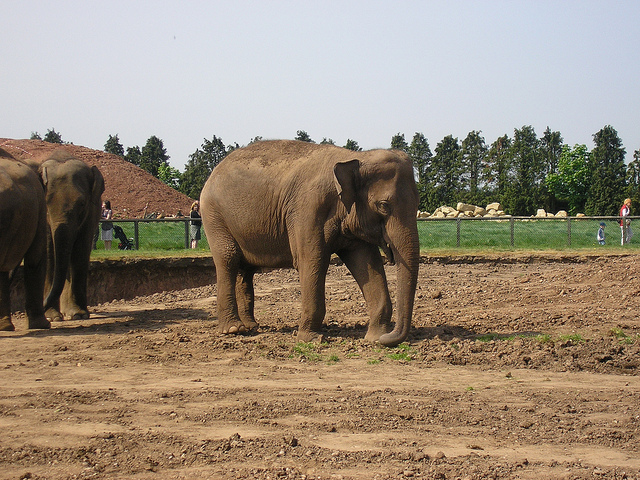

In [12]:
Image.open(image_folder + "/" + batch["image_name"][2])   # put batch index here

In [13]:
print(batch["image_name"])
print("Example question:", batch["question_text"][2])
print("Example answer:", batch["answer_text"][2])

['COCO_train2014_000000105055.jpg', 'COCO_train2014_000000140817.jpg', 'COCO_train2014_000000433435.jpg', 'COCO_train2014_000000056585.jpg']
Example question: Are the elephants fenced in?
Example answer: yes


In [14]:
import torch
import torch.nn as nn
from tqdm import tqdm

# Freeze pretrained CLIP and decoder
for p in vqa_model.clip.parameters():
    p.requires_grad = False
for p in vqa_model.decoder.parameters():
    p.requires_grad = False

# Trainable parts only
trainable_params = list(vqa_model.proj.parameters()) + list(vqa_model.cross_attn.parameters())
optimizer = torch.optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vqa_model.to(device)

# ==========================================================
# Training Loop
# ==========================================================
def train_vqa(model, dataloader, optimizer, tokenizer, epochs=3, device=device):
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}")

        for batch in pbar:
            # Move tensors to device
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # =============================
            # 1️⃣ Extract CLIP features (frozen)
            # =============================
            with torch.no_grad():
                image_feats = model.clip.vision_model(pixel_values=pixel_values).last_hidden_state
                text_feats = model.clip.text_model(
                    input_ids=input_ids, attention_mask=attention_mask
                ).last_hidden_state

            # =============================
            # 2️⃣ Trainable projection + fusion
            # =============================
            proj_feats = model.proj(image_feats)
            fused_feats = model.cross_attn(text_feats, proj_feats)

            # =============================
            # 3️⃣ Prepare decoder inputs (frozen)
            # =============================
            decoder_input_embeds = model.decoder.transformer.wte(labels)
            multimodal_embeds = torch.cat([fused_feats, decoder_input_embeds], dim=1)

            # =============================
            # 4️⃣ Decoder forward + loss
            # =============================
            outputs = model.decoder(inputs_embeds=multimodal_embeds, labels=labels)
            loss = outputs.loss

            # =============================
            # 5️⃣ Backprop only through proj + cross-attn
            # =============================
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_loss = total_loss / len(dataloader)
        print(f"✅ Epoch {epoch+1} | Average Loss: {avg_loss:.4f}")

    print("🎯 Training complete!")


# ==========================================================
# Run training
# ==========================================================
train_vqa(vqa_model, train_loader, optimizer, tokenizer, epochs=3, device=device)


Epoch 1:   0%|          | 0/110940 [00:00<?, ?it/s]


AssertionError: was expecting embedding dimension of 768, but got 512

In [ ]:
train_vqa(vqa_model, train_loader, optimizer, epochs=3)
